# Week 4 class: Network Evolution

In Module Four, you'll explore the evolution of networks over time, including the different models that generate networks with realistic features, such as the Preferential Attachment Model and Small World Networks. 

You will also explore the link prediction problem, where you will learn useful features that can predict whether a pair of disconnected nodes will be connected in the future. In the assignment, you will be challenged to identify which model generated a given network. 

Additionally, you will have the opportunity to combine different concepts of the course by predicting the salary, position, and future connections of the employees of a company using their logs of email exchanges.


https://www.coursera.org/learn/python-social-network-analysis/home/module/4

## Learning Objectives

* Define the degree distribution of a network and use networkX to visualize it.
* Identify the typical properties of real, large networks such as power law like degree distribution, high clustering, and small average shortest paths.
* Describe the mechanics of the Preferential Attachment Model and identify the properties of the networks it generates.
* Describe the mechanics of the Small World Model and identify the properties of the networks it generates.
* Identify and describe several network measures that can be used for link prediction.
* Use NetworkX to create node pair features that are predictive of new edges.
* Use NetworkX to create node features that are predictive of node attributes in a real world setting.

## Imports

In [67]:
import networkx as nx
import social_networks.visualize as viz
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import plotly.graph_objects as go

%matplotlib widget

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Preferential Attachment Model

## Degree Distributions

### Definition

- *degree distribution*, $P(k)$, of a graph is the probability distribution of the degrees over the entire network.
- *in-degree distribution*, $P_{\text{in}}(k)$, of a graph is the probability distribution of the in-degrees over the entire network.

In [ ]:
example_edges = [
    ("B", "A"),
    ("G", "A"),
    ("H", "A"),
    ("C", "B"),
    ("D", "C"),
    ("E", "C"),
    ("F", "D"),
    ("G", "F"),
    ("F", "I"),
    ("H", "G"),
    ("G", "I"),
]

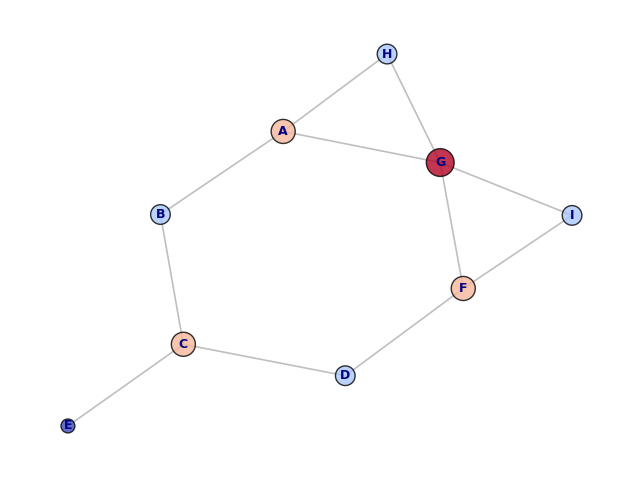

In [ ]:
G = nx.Graph(example_edges)
viz.draw_pretty_hover(G, scale_by_degree=True, color_by_degree=True)

### Draw distribution

In [ ]:
degrees = dict(G.degree())  # G.degree is a `DegreeView` type, not a dict
degree_values = sorted(set(degrees.values()))
num_nodes = nx.number_of_nodes(G)
histogram = [list(degrees.values()).count(i) / num_nodes for i in degree_values]

In [18]:
print(f"{degrees=}")
print(f"{degree_values=}")
print(f"{histogram=}")

degrees={'B': 2, 'A': 3, 'G': 4, 'H': 2, 'C': 3, 'D': 2, 'E': 1, 'F': 3, 'I': 2}
degree_values=[1, 2, 3, 4]
histogram=[0.1111111111111111, 0.4444444444444444, 0.3333333333333333, 0.1111111111111111]


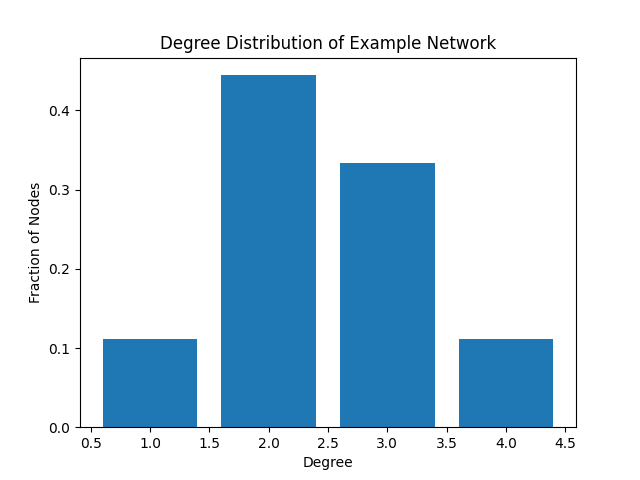

In [ ]:
fig, ax = plt.subplots()
ax.bar(degree_values, histogram)
ax.set(
    xlabel="Degree",
    ylabel="Fraction of Nodes",
    title="Degree Distribution of Example Network",
)
plt.show()

$$
P(1) = \frac{1}{9}, 
P(2) = \frac{4}{9},
P(3) = \frac{1}{3},
P(4) = \frac{1}{9},
$$

## In-Degree distributions

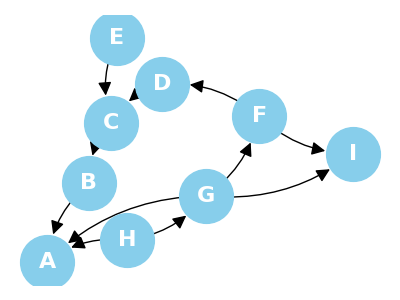

In [10]:
Gin = nx.DiGraph(example_edges)
viz.draw_big_multi_directed(Gin)

### Draw distribution

In [ ]:
in_degrees = dict(Gin.in_degree())  # Gin.in_degree() is a `DegreeView` type, not a dict
in_degree_values = sorted(set(in_degrees.values()))
in_num_nodes = nx.number_of_nodes(Gin)
in_histogram = [
    list(in_degrees.values()).count(i) / in_num_nodes for i in in_degree_values
]

In [21]:
print(f"{in_degrees=}")
print(f"{in_degree_values=}")
print(f"{in_histogram=}")

in_degrees={'B': 1, 'A': 3, 'G': 1, 'H': 0, 'C': 2, 'D': 1, 'E': 0, 'F': 1, 'I': 2}
in_degree_values=[0, 1, 2, 3]
in_histogram=[0.2222222222222222, 0.4444444444444444, 0.2222222222222222, 0.1111111111111111]


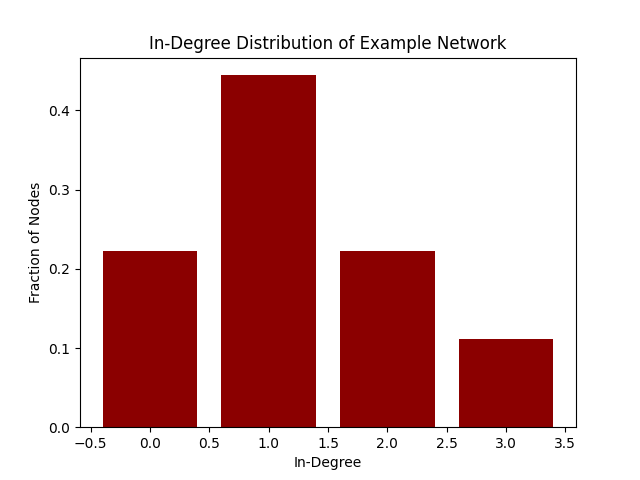

In [ ]:
fig, ax = plt.subplots()
ax.bar(in_degree_values, in_histogram, color="darkred")
ax.set(
    xlabel="In-Degree",
    ylabel="Fraction of Nodes",
    title="In-Degree Distribution of Example Network",
)
plt.show()

## Degree Distributions in Real Networks

### Power law distribution

In a real network, degree distributions often look like a straight line on a log-log scale.

This is indicative of a *power law* distribution.

$$
P(k) = C k^{-\alpha}
$$

where $\alpha$ and $C$ are constants.

In a network with a power law distribution, many nodes have a small degree, and a few nodes have a very large degree.

## Preferential Attachment Model

- Start with 2 connected nodes
- At each step, add an additional node with an edge to an existing node.
- Choose node with probability weighted by degree of each node (higher degree = higher probability of getting the new connection)
- Probability of connecting to node $u$ of degree $k_u$
$$
P = \frac{k_u}{\sum_j{k_j}}
$$

As the number of nodes increases, the degree distribution of the network under the preferential attachment model approaches the power law

$$
P(k) = C k^{-3}
$$

### Generate a preferential attachment network (barabasi-albert graph)

- `barabasi_albert_graph(n, m)` returns a network with `n` nodes.
- Each node attches to `m` nodes according to the preferential attachment model.

In [47]:
num_nodes = 10000
new_edges = 1
Gpam = nx.barabasi_albert_graph(num_nodes, new_edges)

In [ ]:
pam_degrees = dict(Gpam.degree())
pam_degree_values = sorted(set(pam_degrees.values()))
pam_num_nodes = nx.number_of_nodes(Gpam)
pam_histogram = [
    list(pam_degrees.values()).count(i) / pam_num_nodes for i in pam_degree_values
]

In [45]:
print(f"{pam_degrees=}")
print(f"{pam_degree_values=}")
print(f"{pam_histogram=}")

pam_degrees={0: 225, 1: 121, 2: 100, 3: 16, 4: 190, 5: 58, 6: 99, 7: 180, 8: 31, 9: 93, 10: 47, 11: 52, 12: 59, 13: 74, 14: 40, 15: 40, 16: 20, 17: 67, 18: 102, 19: 14, 20: 105, 21: 55, 22: 23, 23: 31, 24: 44, 25: 13, 26: 5, 27: 18, 28: 14, 29: 8, 30: 12, 31: 8, 32: 64, 33: 42, 34: 36, 35: 29, 36: 95, 37: 70, 38: 57, 39: 40, 40: 32, 41: 46, 42: 27, 43: 26, 44: 15, 45: 4, 46: 5, 47: 15, 48: 49, 49: 16, 50: 15, 51: 11, 52: 71, 53: 78, 54: 56, 55: 43, 56: 26, 57: 77, 58: 36, 59: 37, 60: 13, 61: 13, 62: 28, 63: 12, 64: 13, 65: 13, 66: 12, 67: 14, 68: 19, 69: 8, 70: 34, 71: 7, 72: 37, 73: 84, 74: 32, 75: 8, 76: 49, 77: 19, 78: 7, 79: 29, 80: 10, 81: 5, 82: 28, 83: 55, 84: 31, 85: 17, 86: 33, 87: 89, 88: 9, 89: 31, 90: 5, 91: 16, 92: 9, 93: 5, 94: 37, 95: 8, 96: 32, 97: 13, 98: 8, 99: 47, 100: 26, 101: 38, 102: 11, 103: 32, 104: 26, 105: 35, 106: 23, 107: 30, 108: 10, 109: 7, 110: 27, 111: 10, 112: 4, 113: 6, 114: 40, 115: 14, 116: 17, 117: 6, 118: 42, 119: 12, 120: 5, 121: 33, 122: 10, 123:

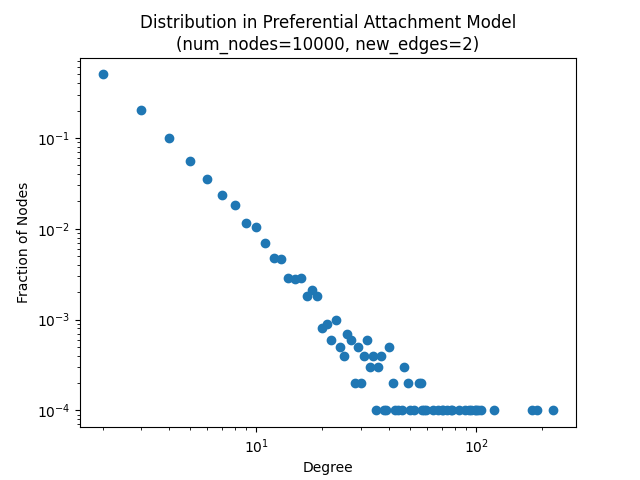

In [ ]:
fig, ax = plt.subplots()
ax.plot(pam_degree_values, pam_histogram, "o")
ax.set(
    xlabel="Degree",
    ylabel="Fraction of Nodes",
    title=f"Distribution in Preferential Attachment Model\n({num_nodes=}, {new_edges=})",
)
ax.set(xscale="log", yscale="log")
plt.show()

### Interactive network (matplotlib)

In [ ]:
def plot_barabasi_mpl(log_n=3, m=1):
    """Plot a preferential attachment model network with mpl"""
    n = 10**log_n
    G = nx.barabasi_albert_graph(n, m)
    degrees = dict(G.degree())
    degree_values = sorted(set(degrees.values()))
    num_nodes = G.number_of_nodes()
    histogram = [list(degrees.values()).count(i) / num_nodes for i in degree_values]

    fig, ax = plt.subplots()
    ax.plot(degree_values, histogram, "o")
    ax.set(
        xlabel="Degree",
        ylabel="Fraction of Nodes",
        title=f"Distribution in Preferential Attachment Model\n({n=:,}, {m=})",
    )
    ax.set(xscale="log", yscale="log")
    plt.show()

Create interactive sliders

In [ ]:
interact(
    plot_barabasi_mpl,
    log_n=IntSlider(min=1, max=6, step=1, value=3),
    m=IntSlider(min=1, max=10, step=1, value=1),
)

interactive(children=(IntSlider(value=3, description='log_n', max=6, min=1), IntSlider(value=1, description='m…

<function __main__.plot_barabasi_mpl(log_n=3, m=1)>

### Interactive network (plotly)

In [ ]:
def plot_barabasi_plotly(log_n=3, m=1):
    """Plot a preferential attachment model network with plotly"""
    n = 10**log_n
    G = nx.barabasi_albert_graph(n, m)

    degrees = dict(G.degree())
    degree_values = sorted(set(degrees.values()))
    num_nodes = G.number_of_nodes()
    histogram = [list(degrees.values()).count(i) / num_nodes for i in degree_values]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=degree_values,
            y=histogram,
            mode="markers",
            marker=dict(size=8, color="red"),
            name="Degree Distribution",
        )
    )

    fig.update_layout(
        title=f"Preferential Attachment Model<br>n={num_nodes}, m={m}",
        xaxis_title="Degree",
        yaxis_title="Fraction of Nodes",
        xaxis_type="log",
        yaxis_type="log",
        template="plotly_white",
    )

    fig.show()

In [ ]:
interact(
    plot_barabasi_plotly,
    log_n=IntSlider(min=1, max=6, step=1, value=3),
    m=IntSlider(min=1, max=10, step=1, value=1),
)

interactive(children=(IntSlider(value=3, description='log_n', max=6, min=1), IntSlider(value=1, description='m…

<function __main__.plot_barabasi_plotly(log_n=3, m=1)>

#### Draw network with plotly

In [ ]:
def draw_barabasi_graph(log_n=2, m=1):
    n = 10**log_n
    G = nx.barabasi_albert_graph(n, m)

    # Layout: get node positions using spring layout (force-directed)
    pos = nx.spring_layout(G, seed=42)

    # Extract edge coordinates
    edge_x = []
    edge_y = []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x.extend([x0, x1, None])  # None separates segments
        edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=0.5, color="#888"),
        hoverinfo="none",
        mode="lines",
    )

    # Extract node coordinates and degrees
    node_x = []
    node_y = []
    node_deg = []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        node_deg.append(G.degree(node))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers",
        hoverinfo="text",
        marker=dict(
            showscale=True,
            colorscale="YlGnBu",
            color=node_deg,
            size=6,
            colorbar=dict(thickness=15, title=dict(text="Node Degree"), xanchor="left"),
            line_width=0.5,
        ),
        text=[f"Node {i}<br>Degree {deg}" for i, deg in zip(G.nodes(), node_deg)],
    )

    # Combine in a Plotly Figure
    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=dict(
                text=f"Barabási–Albert Graph (n={n}, m={m})", font=dict(size=16)
            ),
            showlegend=False,
            hovermode="closest",
            margin=dict(b=20, l=5, r=5, t=40),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        ),
    )

    fig.show()


# Create interactive controls
interact(
    draw_barabasi_graph,
    log_n=IntSlider(min=1, max=4, step=1, value=2),  # n from 10 to 10,000
    m=IntSlider(min=1, max=10, step=1, value=1),
)

interactive(children=(IntSlider(value=2, description='log_n', max=4, min=1), IntSlider(value=1, description='m…

<function __main__.draw_barabasi_graph(log_n=2, m=1)>